In [2]:
import torch

# Create a simple linear regression model
weight = 0.7
bias = 0.3

# Create an array of X
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)

y = weight * X + bias


In [3]:
len(X), len(y)

(50, 50)

In [4]:
# Split the data to train-val-test


train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [33]:
# Plot the values
import matplotlib.pyplot as plt


def plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=None,
) -> None:

    # Define the figure
    plt.figure(figsize=(10, 7))

    # Plot the train data
    plt.scatter(train_data, train_labels, c="b", s=4, label="Train Data")
    # Plot the test data
    plt.scatter(test_data, test_labels, c="g", s=4, label="Test data")

    # If predictions:
    if predictions is not None:
        plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

    plt.legend(prop={"size": 14})

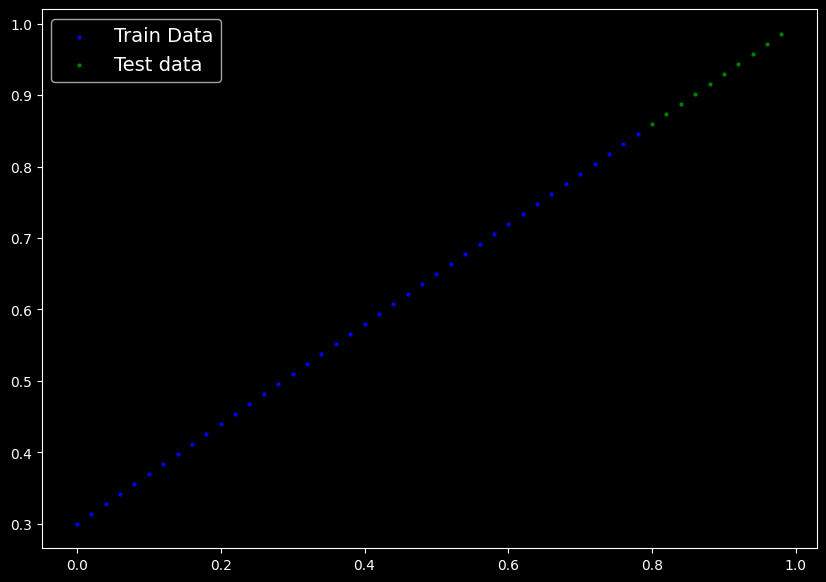

In [6]:
plot_predictions()

In [23]:
# Let's create our first model
from torch import nn


class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(
            torch.randn(
                1,  # Initialize the weight with a random value
                requires_grad=True,  # Should the gradient of this parameter be calculate during gradient descent ?
                dtype=torch.float,  # PyTorch's default datatype being torch.float32
            )
        )
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float))

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.weights * X + self.bias

In [8]:
# Checking the contents of the model

# Set the seed for reproducibility
torch.manual_seed(42)
# Create an instance of the LinearRegression Model created
model_0 = LinearRegression()

# Check the parameters of the model
model_0._parameters

{'weights': Parameter containing:
 tensor([0.3367], requires_grad=True),
 'bias': Parameter containing:
 tensor([0.1288], requires_grad=True)}

In [9]:
# List named parameters()
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [10]:
# Target weights and bias
weight, bias

(0.7, 0.3)

Making predictions using `torch.inference_mode()`

To check the model's power, let's see how well it predict `y_test`, based on `x_test`.

When we pass `x_test` data through the model, it goes through the `forward` pass method

In [11]:
# Making predictions
with torch.inference_mode():
    y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

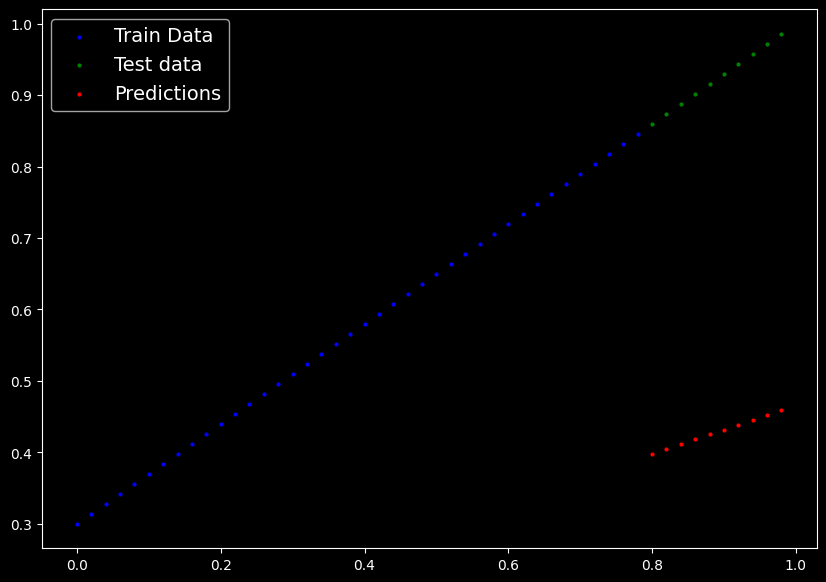

In [12]:
# Lets plot the predictions
plot_predictions(predictions=y_preds)


In [13]:
# Training the model

# Loss  Funtion
loss_fn = torch.nn.L1Loss()

# Set an optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)  # Learning rate


In [14]:
# Write the training loop
EPOCHS = 200
epoch_count: list[int] = []
train_loss_count: list[float] = []
test_loss_count: list[float] = []


for epoch in range(EPOCHS):
    # Set to train mode, the default mode of the model
    model_0.train()

    # 1. Do the forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    train_loss = loss_fn(y_pred, y_train)
    # print(f"loss: {loss}")

    # 3. Zero the optimizer gradients
    optimizer.zero_grad()

    # 4. Backpropagation
    train_loss.backward()

    # 5. Gradient descent (Optimization)
    optimizer.step()

    # Test code
    model_0.eval()  # Turns off various settings like BatchNorm and Dropout since we dont need them during the evaluation

    # Set the inference_mode() context window
    with torch.inference_mode():  # Turns off the gradient tracking since we are not training the parameters anymore
        # Do the forward pass
        y_pred_test = model_0(X_test)

        # Calculate the test loss

        test_loss = loss_fn(y_pred_test, y_test)

    if epoch % 10 == 0:
        print(f"Epoch : {epoch} | TrainLoss : {train_loss} | TestLoss : {test_loss}")
        # Track the experiment
        epoch_count.append(epoch)
        train_loss_count.append(train_loss.item())
        test_loss_count.append(test_loss.item())

        # print the model.state_dict()
        print(model_0.state_dict())

Epoch : 0 | TrainLoss : 0.31288138031959534 | TestLoss : 0.48106518387794495
OrderedDict([('weights', tensor([0.3406])), ('bias', tensor([0.1388]))])
Epoch : 10 | TrainLoss : 0.1976713240146637 | TestLoss : 0.3463551998138428
OrderedDict([('weights', tensor([0.3796])), ('bias', tensor([0.2388]))])
Epoch : 20 | TrainLoss : 0.08908725529909134 | TestLoss : 0.21729660034179688
OrderedDict([('weights', tensor([0.4184])), ('bias', tensor([0.3333]))])
Epoch : 30 | TrainLoss : 0.053148526698350906 | TestLoss : 0.14464017748832703
OrderedDict([('weights', tensor([0.4512])), ('bias', tensor([0.3768]))])
Epoch : 40 | TrainLoss : 0.04543796554207802 | TestLoss : 0.11360953003168106
OrderedDict([('weights', tensor([0.4748])), ('bias', tensor([0.3868]))])
Epoch : 50 | TrainLoss : 0.04167863354086876 | TestLoss : 0.09919948130846024
OrderedDict([('weights', tensor([0.4938])), ('bias', tensor([0.3843]))])
Epoch : 60 | TrainLoss : 0.03818932920694351 | TestLoss : 0.08886633068323135
OrderedDict([('wei

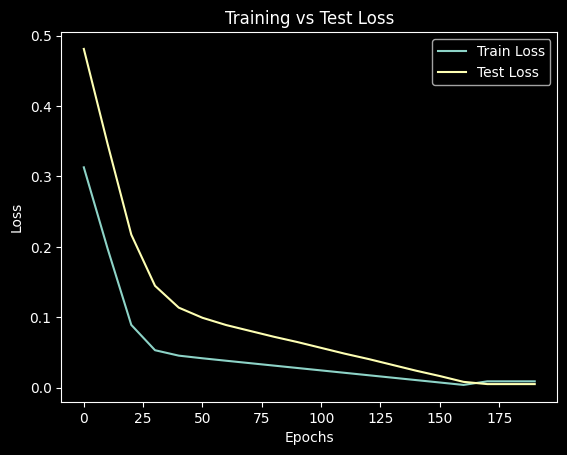

In [15]:
plt.plot(epoch_count, train_loss_count, label="Train Loss")
plt.plot(epoch_count, test_loss_count, label="Test Loss")
plt.title("Training vs Test Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

### Model Save/Load
There are a couple of ways to save and load a pytorch model.
1. `torch.save()` -> Saves a PyTorch object in Python's pickle format.
2. `torch.load()` -> Loads a saved PyTorch object.
3. `torch.nn.Module.load_state_dict()` -> Load the model's saved state_dict




In [19]:
# Save our PyTorch Model
from pathlib import Path

# Create a models directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_FILE_PATH = MODEL_PATH / "01_pytorch_workflow_model.pth"

# torch.save(model_0.state_dict())
torch.save(obj=model_0.state_dict(), f=MODEL_FILE_PATH)
print(f"Model saved to : {MODEL_FILE_PATH}")

Model saved to : models\01_pytorch_workflow_model.pth


In [19]:
weight, bias

(0.7, 0.3)

In [22]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

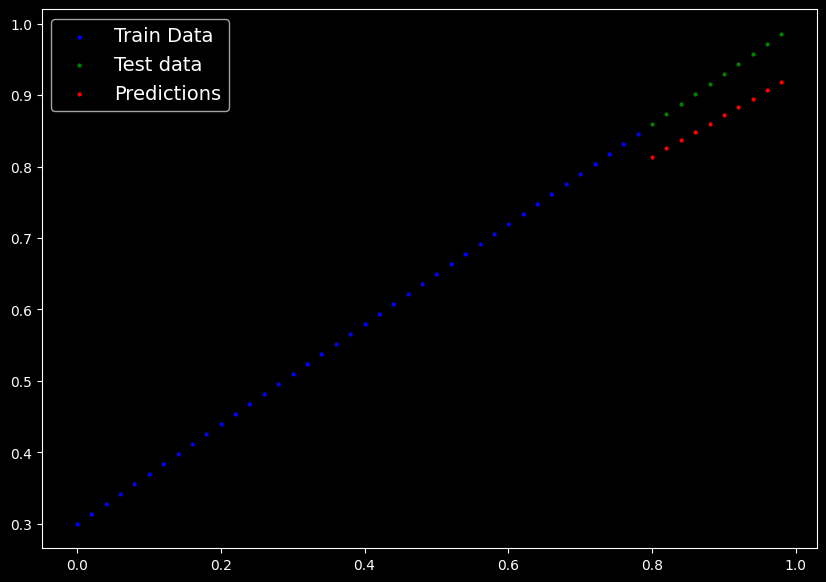

In [20]:
plot_predictions(predictions=y_preds)  # Predictions before training

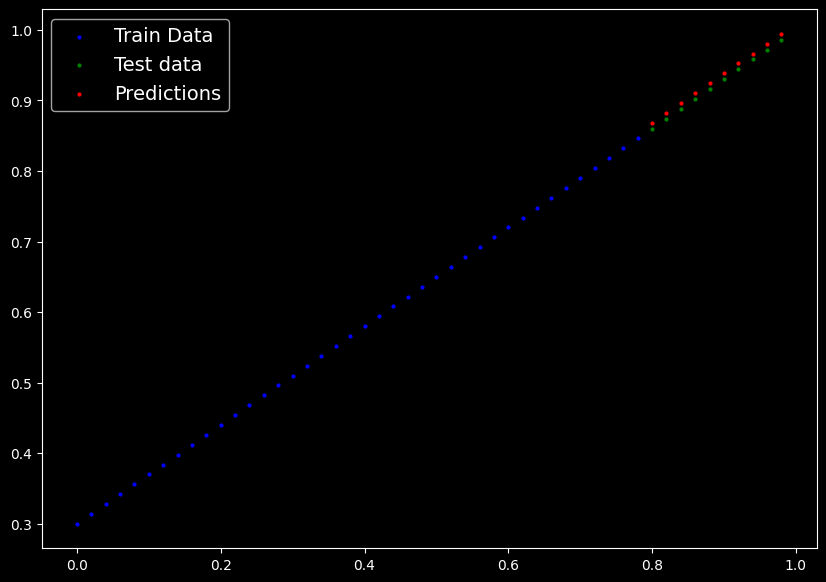

In [21]:
# Let's generate new predicitons and plot it
with torch.inference_mode():
    y_pred_new = model_0(X_test)

plot_predictions(predictions=y_pred_new)

In [25]:
# Let's load the saved state_dict()
# Inorder to load the saved state_dict of the model, we first need to instantiate a new instance
# of the LinearRegression Model and then overwrite the state_dict()

LOADED_MODEL = LinearRegression()

print(
    f"State Dict of the loaded model before overwriting the saved state_dict: {LOADED_MODEL.state_dict()}"
)

# Now let's overwrite the state_dict() of the new instance with the saved state_dict
LOADED_MODEL.load_state_dict(torch.load(MODEL_FILE_PATH), strict=True)

print(
    f"State Dict of the loaded model after overwriting the saved state_dict: {LOADED_MODEL.state_dict()}"
)


State Dict of the loaded model before overwriting the saved state_dict: OrderedDict([('weights', tensor([-1.1229])), ('bias', tensor([-0.1863]))])
State Dict of the loaded model after overwriting the saved state_dict: OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])


In [1]:
# Let's bring the bits and pieces we had so far together

import matplotlib.pyplot as plt
import torch
from torch import nn

# Check PyTorch version
print(torch.__version__)

2.8.0+cpu


In [3]:
# Create device-agnostic code
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cpu'

In [12]:
# Let's create some data for the linear regression
weight: float = 0.7
bias: float = 0.3
X: torch.Tensor = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y: torch.Tensor = weight * X + bias


In [13]:
X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [29]:
# Split the data
train_split: int = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [30]:
len(X_train), len(X_test), len(y_train), len(y_test)

(40, 10, 40, 10)

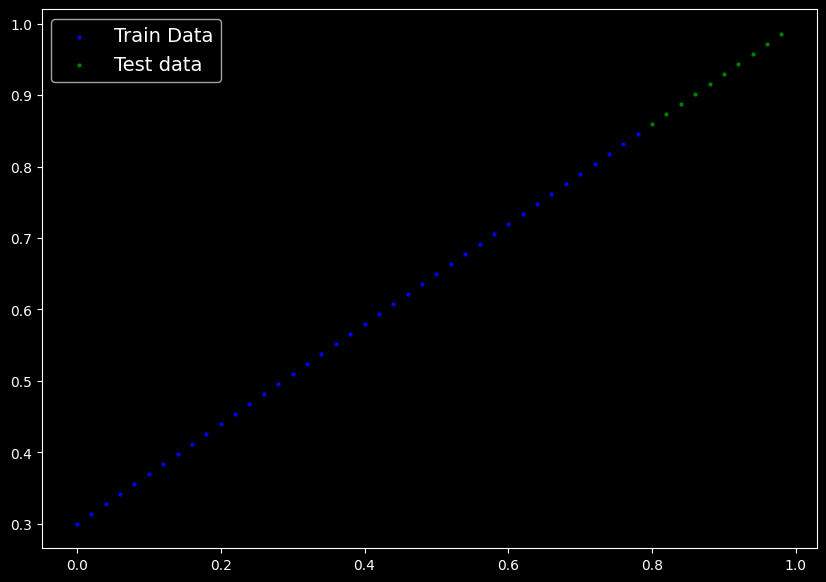

In [34]:
plot_predictions(
    train_data=X_train, train_labels=y_train, test_data=X_test, test_labels=y_test
)

In [50]:
## Building a PyTorch Linear Model


class LinearRegressionV2(nn.Module):
    def __init__(self) -> None:
        super().__init__()

        self.linear_layer = nn.Linear(in_features=1, out_features=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)

In [51]:
# Set the manual seed
torch.manual_seed(42)
model_1 = LinearRegressionV2()
model_1, model_1.state_dict()

(LinearRegressionV2(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [52]:
# Set the model to use the target device
model_1.to(DEVICE)

LinearRegressionV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [53]:
next((model_1.parameters())).device


device(type='cpu')

In [57]:
# Set the data on the target device as well
X_train = X_train.to(DEVICE)
X_test = X_test.to(DEVICE)
y_train = y_train.to(DEVICE)
y_test = y_test.to(DEVICE)

In [60]:
X_train.device, X_test.device, y_train.device, y_test.device

(device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'),
 device(type='cpu'))

In [54]:
# Setup loss function
loss_fn = nn.L1Loss()  # Same as MAE

# Setup optimizer
optimizer = torch.optim.SGD(params=model_1.parameters(), lr=0.01)


In [55]:
# Let's write the training loop
NUM_EPOCHS = 200
epoch_count = []
train_loss_count = []
test_loss_count = []
for epoch in range(NUM_EPOCHS):
    # Set the model in train mode explicitly, although that is the default behaviour
    model_1.train()

    # Perform the forward pass
    y_pred = model_1(X_train)

    # Compute the loss
    train_loss = loss_fn(y_pred, y_train)

    # Zero the optimizer grads for future epochs so that they dont accumulate
    optimizer.zero_grad()

    # Backpropagation
    train_loss.backward()

    # SGD (Perform the opimitization step)
    optimizer.step()

    # Testing

    model_1.eval()

    with torch.inference_mode():
        y_pred_test = model_1(X_test)

        test_loss = loss_fn(y_pred_test, y_test)

        # Record the metrics
        epoch_count.append(epoch)
        train_loss_count.append(train_loss.item())
        test_loss_count.append(test_loss.item())

    if epoch % 10 == 0:
        print(f"Epoch : {epoch} | TrainLoss: {train_loss} | TestLoss: {test_loss}")
        print(model_1.state_dict())

Epoch : 0 | TrainLoss: 0.5551779866218567 | TestLoss: 0.5739762187004089
OrderedDict([('linear_layer.weight', tensor([[0.7606]])), ('linear_layer.bias', tensor([0.8200]))])
Epoch : 1 | TrainLoss: 0.5436569452285767 | TestLoss: 0.5605052709579468
OrderedDict([('linear_layer.weight', tensor([[0.7567]])), ('linear_layer.bias', tensor([0.8100]))])
Epoch : 2 | TrainLoss: 0.5321359634399414 | TestLoss: 0.5470342040061951
OrderedDict([('linear_layer.weight', tensor([[0.7528]])), ('linear_layer.bias', tensor([0.8000]))])
Epoch : 3 | TrainLoss: 0.5206149816513062 | TestLoss: 0.5335632562637329
OrderedDict([('linear_layer.weight', tensor([[0.7489]])), ('linear_layer.bias', tensor([0.7900]))])
Epoch : 4 | TrainLoss: 0.5090939998626709 | TestLoss: 0.520092248916626
OrderedDict([('linear_layer.weight', tensor([[0.7450]])), ('linear_layer.bias', tensor([0.7800]))])
Epoch : 5 | TrainLoss: 0.49757298827171326 | TestLoss: 0.5066213011741638
OrderedDict([('linear_layer.weight', tensor([[0.7411]])), ('li

In [56]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

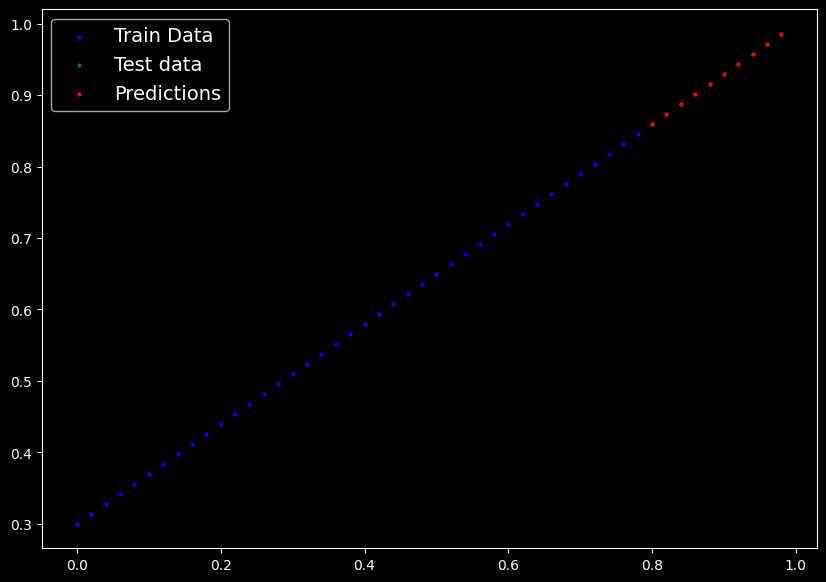

In [61]:
# Let's plot the predictions
plot_predictions(predictions=y_pred_test)

In [67]:
from pathlib import Path

# Save the model
MODEL_FILE_PATH = Path("models")
MODEL_FILE_PATH.mkdir(mode=511, parents=True, exist_ok=True)
MODEL_NAME = "01_LinearRegression_V2.pth"

MODEL_SAVE_PATH = MODEL_FILE_PATH / MODEL_NAME
MODEL_SAVE_PATH

WindowsPath('models/01_LinearRegression_V2.pth')

In [68]:
torch.save(obj=model_1.state_dict(), f=MODEL_SAVE_PATH)
print(f"LinearRegressionV2 model saved to : {MODEL_SAVE_PATH}")

LinearRegressionV2 model saved to : models\01_LinearRegression_V2.pth


In [69]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]])),
             ('linear_layer.bias', tensor([0.3025]))])

In [77]:
# Let's load the saved model
loaded_model_v2 = LinearRegressionV2()
loaded_model_v2

LinearRegressionV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [78]:
loaded_model_v2.state_dict()

OrderedDict([('linear_layer.weight', tensor([[-0.4869]])),
             ('linear_layer.bias', tensor([0.5873]))])

In [79]:
print(
    f"State Dict before loading the trained parameters: {loaded_model_v2.state_dict()}"
)
loaded_model_v2_with_trained_params = loaded_model_v2.load_state_dict(
    torch.load(f=MODEL_SAVE_PATH), strict=True
)
print(
    f"State Dict after loading the trained parameters : {loaded_model_v2.state_dict()}"
)

State Dict before loading the trained parameters: OrderedDict([('linear_layer.weight', tensor([[-0.4869]])), ('linear_layer.bias', tensor([0.5873]))])
State Dict after loading the trained parameters : OrderedDict([('linear_layer.weight', tensor([[0.6968]])), ('linear_layer.bias', tensor([0.3025]))])


In [80]:
# Send the loaded model to the device
loaded_model_v2.to(DEVICE)

LinearRegressionV2(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [81]:
next(loaded_model_v2.parameters()).device

device(type='cpu')

In [84]:
# Let's evaluate and make some predictions from the loaded model
loaded_model_v2.eval()
with torch.inference_mode():
    # Perform the forward pass
    y_pred_from_loaded_model_v2 = loaded_model_v2(X_test)

y_pred_from_loaded_model_v2.shape

torch.Size([10, 1])

In [89]:
y_pred_from_loaded_model_v2 == y_pred_test

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [85]:
y_test.shape

torch.Size([10, 1])

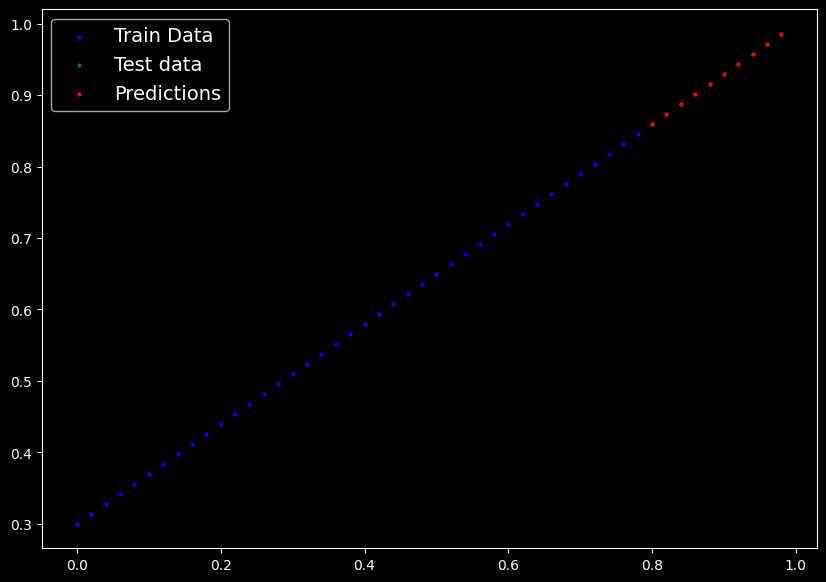

In [91]:
plot_predictions(
    train_data=X_train,
    train_labels=y_train,
    test_data=X_test,
    test_labels=y_test,
    predictions=y_pred_from_loaded_model_v2,
)